In [1]:
import torch
import numpy as np
import json

import matplotlib.pyplot as plt
import numpy as np
import torch
from jaxtyping import Int, Float
from tqdm import tqdm
from scipy.fft import fft2
from scipy.optimize import curve_fit

from attn_analysis.attn_figure_funcs import gram_fft



In [3]:
# load activations for each prompt

def load_activations(
		model_name: str,
	) -> tuple[
		list[dict],
		list[np.lib.npyio.NpzFile],
	]:
	with open(f"../attn_data/{model_name}/prompts.jsonl") as f:
		prompts = [json.loads(line) for line in f]
	
	activations = [
		np.load(f"../attn_data/{model_name}/prompts/{p['hash']}/activations.npz")
		for p in prompts
	]

	return prompts, activations

PROMPTS, ACTIVATIONS = load_activations("pythia-14m")


In [4]:
ACTIVATIONS[0]

NpzFile '../attn_data/pythia-14m/prompts/-N_K8tWwvqf9kgl298ak3g/activations.npz' with keys: blocks.0.attn.hook_pattern, blocks.1.attn.hook_pattern, blocks.2.attn.hook_pattern, blocks.3.attn.hook_pattern, blocks.4.attn.hook_pattern...

In [5]:
for i in range(5):
	print(PROMPTS[i]['text'])
	print("="*50)

Volunteer Services

Volunteer Services

As Charleston Area Medical Center volunteers, our mission is to serve as support for patients, families and hospital staff, and to provide a caring, comforting and courteous environment.

Volunteers at CAMC bring their unique personalities and skills to our hospital. They range in age from 15 to 99. Our ranks are made up of men and women; students and retirees; homemakers and business people. Last year, 334 volunteers contributed over 36,000 hours to our hospitals and Cancer Center.

We are looking for volunteers who exemplify CAMC's core values of respect, integrity, stewardship, quality, service with compassion and safety. These volunteers will help us with our mission of "striving to provide the best health care to every patient, every day."
jOOQ on The ORM Foundation?

I am the developer of jOOQ, a Java database abstraction framework. I was wondering whether jOOQ might be an interesting tool for discussion on your website, even if it is not e

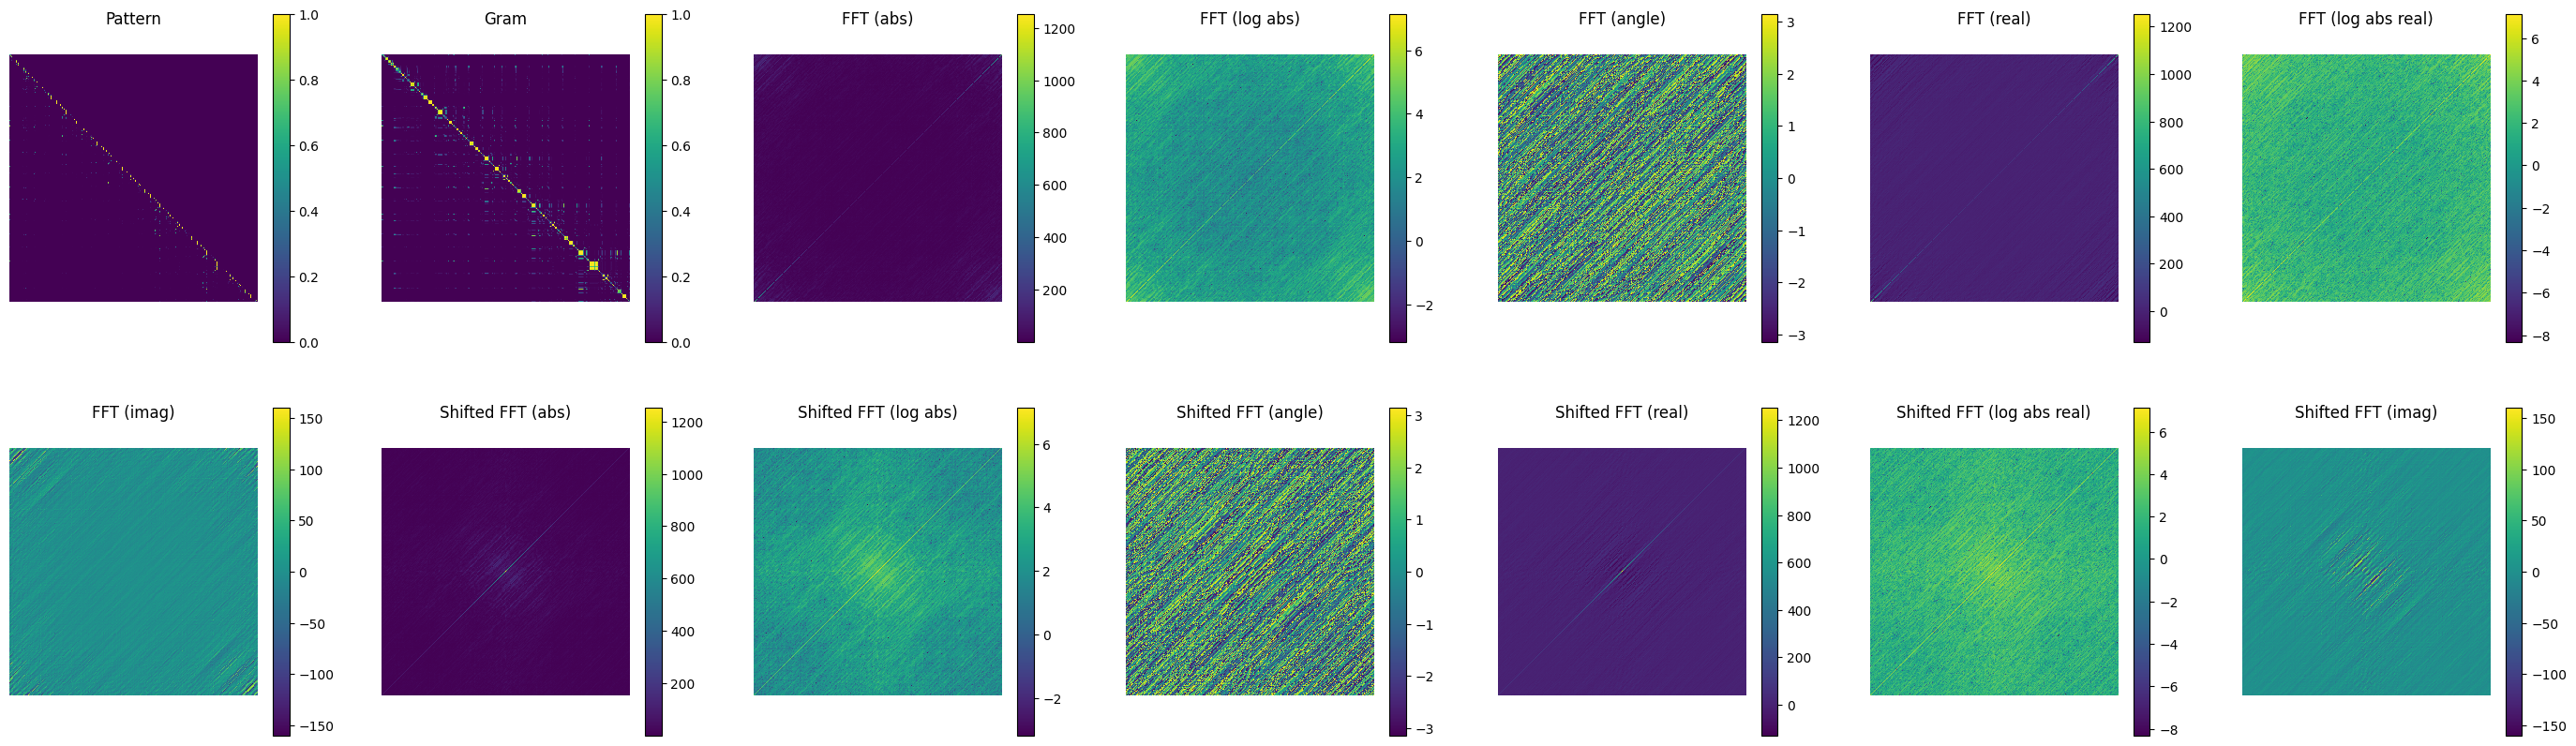

(<Figure size 3500x1000 with 28 Axes>,
 array([[<Axes: title={'center': 'Pattern'}>,
         <Axes: title={'center': 'Gram'}>,
         <Axes: title={'center': 'FFT (abs)'}>,
         <Axes: title={'center': 'FFT (log abs)'}>,
         <Axes: title={'center': 'FFT (angle)'}>,
         <Axes: title={'center': 'FFT (real)'}>,
         <Axes: title={'center': 'FFT (log abs real)'}>],
        [<Axes: title={'center': 'FFT (imag)'}>,
         <Axes: title={'center': 'Shifted FFT (abs)'}>,
         <Axes: title={'center': 'Shifted FFT (log abs)'}>,
         <Axes: title={'center': 'Shifted FFT (angle)'}>,
         <Axes: title={'center': 'Shifted FFT (real)'}>,
         <Axes: title={'center': 'Shifted FFT (log abs real)'}>,
         <Axes: title={'center': 'Shifted FFT (imag)'}>]], dtype=object))

In [6]:

def plot_pattern_info(
		pattern: Float[np.ndarray, "n_ctx n_ctx"],
        show: bool = True,
    ) -> tuple[plt.Figure, plt.Axes]:

    gram = pattern @ pattern.T
    fft = fft2(gram)
    fft_shifted = np.fft.fftshift(fft)
    data: dict = {
        "Pattern": pattern,
        "Gram": gram,
        "FFT (abs)": np.abs(fft),
        "FFT (log abs)": np.log(np.abs(fft)),
        "FFT (angle)": np.angle(fft),
        "FFT (real)": np.real(fft),
        "FFT (log abs real)": np.log(np.abs(np.real(fft))),
        "FFT (imag)": np.imag(fft),
        "Shifted FFT (abs)": np.abs(fft_shifted),
        "Shifted FFT (log abs)": np.log(np.abs(fft_shifted)),
        "Shifted FFT (angle)": np.angle(fft_shifted),
        "Shifted FFT (real)": np.real(fft_shifted),
        "Shifted FFT (log abs real)": np.log(np.abs(np.real(fft_shifted))),
        "Shifted FFT (imag)": np.imag(fft_shifted),
    }

    # Create subplots and add colorbars using a loop
    n_data: int = len(data)
    n_cols: int = round(n_data / 2)
    fig, axs = plt.subplots(2, n_cols, figsize=(5 * n_cols, 10))
    for ax, (title, datum) in zip(axs.flat[:n_data], data.items()):
        cax = ax.matshow(datum)
        fig.colorbar(cax, ax=ax)
        ax.set_title(title)
        ax.axis("off")

    if show:
        plt.show()
    
    return fig, axs


plot_pattern_info(ACTIVATIONS[1]["blocks.4.attn.hook_pattern"][0,0])

In [11]:
def plot_comparison(
    original_data: np.ndarray,
    fitted_model: np.ndarray,
    freqs: np.ndarray,
    title: str = "FFT Data vs. Fitted Model and Difference"
) -> None:
    """Plot original data, fitted model, and their difference side by side."""
    difference = original_data - fitted_model
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title)
    
    # Find common vmin/vmax for original and fitted data
    vmin = min(original_data.min(), fitted_model.min())
    vmax = max(original_data.max(), fitted_model.max())
    
    # Original FFT Data
    im0 = axes[0].imshow(
        original_data, 
        extent=(freqs.min(), freqs.max(), freqs.min(), freqs.max()),
        origin='lower',
        vmin=vmin,
        vmax=vmax
    )
    axes[0].set_title('Original FFT Data')
    axes[0].set_xlabel('Frequency fx')
    axes[0].set_ylabel('Frequency fy')
    fig.colorbar(im0, ax=axes[0], orientation='vertical')
    
    # Fitted Model
    im1 = axes[1].imshow(
        fitted_model, 
        extent=(freqs.min(), freqs.max(), freqs.min(), freqs.max()),
        origin='lower',
        vmin=vmin,
        vmax=vmax
    )
    axes[1].set_title('Fitted Gaussian Model')
    axes[1].set_xlabel('Frequency fx')
    axes[1].set_ylabel('Frequency fy')
    fig.colorbar(im1, ax=axes[1], orientation='vertical')
    
    # Difference plot with symmetric red-blue colormap
    diff_vmax = max(abs(difference.min()), abs(difference.max()))
    im2 = axes[2].imshow(
        difference, 
        extent=(freqs.min(), freqs.max(), freqs.min(), freqs.max()),
        origin='lower',
        cmap='RdBu_r',  # Red-Blue diverging colormap
        vmin=-diff_vmax,     # Symmetric limits around zero
        vmax=diff_vmax
    )
    axes[2].set_title('Difference (Original - Fitted)')
    axes[2].set_xlabel('Frequency fx')
    axes[2].set_ylabel('Frequency fy')
    fig.colorbar(im2, ax=axes[2], orientation='vertical')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [25]:
class FFTModel(torch.nn.Module):
    """PyTorch model for fitting FFT patterns with Gaussian components."""
    def __init__(self):
        super(FFTModel, self).__init__()
        # Initialize parameters with default values
        self.A_cross = torch.nn.Parameter(torch.tensor(1.0))
        self.sigma_cross = torch.nn.Parameter(torch.tensor(0.01))
        self.A_diag = torch.nn.Parameter(torch.tensor(5.0))
        self.sigma_diag = torch.nn.Parameter(torch.tensor(0.01))
        self.B = torch.nn.Parameter(torch.tensor(1.0))

    @classmethod
    def smart_init(cls, pattern: np.ndarray) -> "FFTModel":
        """
        Create a model with parameters initialized from pattern statistics using intelligent estimates.
        
        Args:
            pattern: The attention pattern to analyze
                
        Returns:
            FFTModel with intelligently guessed initial parameters
        """
        model = cls()
        
        # Compute gram and FFT
        gram = pattern @ pattern.T
        fft = np.fft.fft2(gram)
        fft_shifted = np.fft.fftshift(fft)
        log_fft = np.log(np.abs(fft_shifted) + 1e-8)  # Add epsilon to prevent log(0)
        
        # Get dimensions
        N = log_fft.shape[0]
        center = N // 2
        
        # Create a mask to exclude central peaks for background estimation
        exclusion_size = N // 4
        mask = np.ones_like(log_fft, dtype=bool)
        start = center - exclusion_size // 2
        end = center + exclusion_size // 2
        mask[start:end, start:end] = False
        background_values = log_fft[mask]
        
        # Estimate background level (B) from areas excluding peaks
        B_init = float(np.median(background_values))
        
        # Estimate cross amplitude (A_cross) from central horizontal and vertical lines
        horizontal_line = log_fft[center, :]
        vertical_line = log_fft[:, center]
        A_cross_init = float(max(horizontal_line.max(), vertical_line.max()) - B_init)
        
        # Estimate cross width (sigma_cross) from horizontal and vertical lines
        def estimate_sigma(line: np.ndarray, B_init: float) -> float:
            peak = line.max()
            half_max = peak - (peak - B_init) / 2
            indices_above_half_max = np.where(line > half_max)[0]
            if len(indices_above_half_max) >= 2:
                fwhm = indices_above_half_max[-1] - indices_above_half_max[0]
                sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))  # Convert FWHM to sigma
                return float(sigma / (N / 2))  # Normalize by size
            return 0.01  # Default small value if estimation is not possible

        sigma_cross_init = max(
            estimate_sigma(horizontal_line, B_init),
            estimate_sigma(vertical_line, B_init)
        )
        
        # Estimate diagonal amplitude (A_diag) from main and anti-diagonal lines
        diagonal_line = np.diagonal(log_fft)
        anti_diagonal_line = np.diagonal(np.fliplr(log_fft))
        A_diag_init = float(max(diagonal_line.max(), anti_diagonal_line.max()) - B_init)
        
        # Estimate diagonal width (sigma_diag) from diagonal lines
        sigma_diag_init = max(
            estimate_sigma(diagonal_line, B_init),
            estimate_sigma(anti_diagonal_line, B_init)
        )
        
        # Set parameters with estimated values
        model.B.data = torch.tensor(B_init, dtype=torch.float32)
        model.A_cross.data = torch.tensor(A_cross_init, dtype=torch.float32)
        model.sigma_cross.data = torch.tensor(sigma_cross_init, dtype=torch.float32)
        model.A_diag.data = torch.tensor(A_diag_init, dtype=torch.float32)
        model.sigma_diag.data = torch.tensor(sigma_diag_init, dtype=torch.float32)
        
        return model

    def forward(self, coords: torch.Tensor) -> torch.Tensor:
        """Forward pass of the model."""
        fx, fy = coords
        # Vertical and horizontal components
        vertical = self.A_cross * torch.exp(-fx**2 / (2 * self.sigma_cross**2))
        horizontal = self.A_cross * torch.exp(-fy**2 / (2 * self.sigma_cross**2))
        
        # Diagonal component
        theta = torch.tensor(torch.pi / 4)
        fx_prime = fx * torch.cos(theta) + fy * torch.sin(theta)
        diag = self.A_diag * torch.exp(-fx_prime**2 / (2 * self.sigma_diag**2))
        
        return (vertical + horizontal + diag + self.B).view(-1)

In [26]:
def fit_pattern(
    pattern: np.ndarray,
    n_iterations: int = 5000,
    learning_rate: float = 0.01
) -> tuple[FFTModel, np.ndarray, np.ndarray]:
    """Fit a pattern with the FFTModel."""
    # Prepare data
    gram = pattern @ pattern.T
    fft_shifted = np.log(np.abs(np.fft.fftshift(np.fft.fft2(gram))))
    
    N = fft_shifted.shape[0]
    freqs = np.fft.fftshift(np.fft.fftfreq(N))
    fx, fy = np.meshgrid(freqs, freqs)
    
    # Convert to torch tensors
    coords = torch.tensor(np.vstack((fx.ravel(), fy.ravel())), dtype=torch.float32)
    fft_data_flat_torch = torch.tensor(fft_shifted.ravel(), dtype=torch.float32)
    
    # Setup model and optimizer
    model = FFTModel.smart_init(pattern)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    loss_fn = torch.nn.MSELoss()
    
    # List to store losses
    losses = []
    
    # Training loop
    def closure():
        optimizer.zero_grad()
        output = model(coords)
        loss = loss_fn(output, fft_data_flat_torch)
        loss.backward()
        losses.append(loss.item())
        return loss
    
    # Run optimization with progress bar
    for _ in tqdm(range(n_iterations)):
        optimizer.step(closure)
    
    # Plot loss curve
    plt.figure(figsize=(10, 6))
    plt.loglog(range(1, len(losses) + 1), losses)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.xlabel('Iteration')
    plt.ylabel('Loss (MSE)')
    plt.title('Training Loss Over Time')
    plt.show()
    
    # Get fitted model
    fitted_model = model(coords).detach().numpy().reshape(fft_shifted.shape)
    
    return model, fitted_model, freqs

100%|██████████| 10000/10000 [00:44<00:00, 225.14it/s]


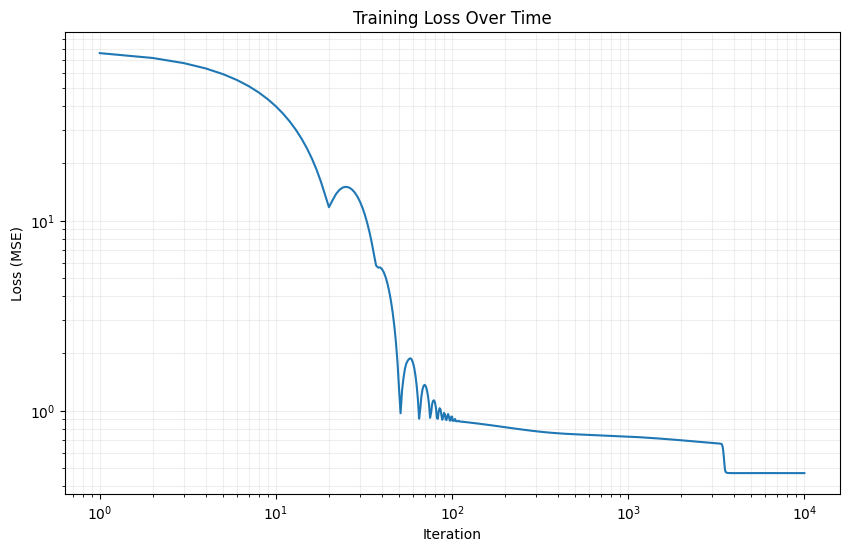

A_cross: 0.9107303619384766
sigma_cross: 0.14736564457416534
A_diag: 2.6059083938598633
sigma_diag: -0.00016918749315664172
B: 1.7502162456512451


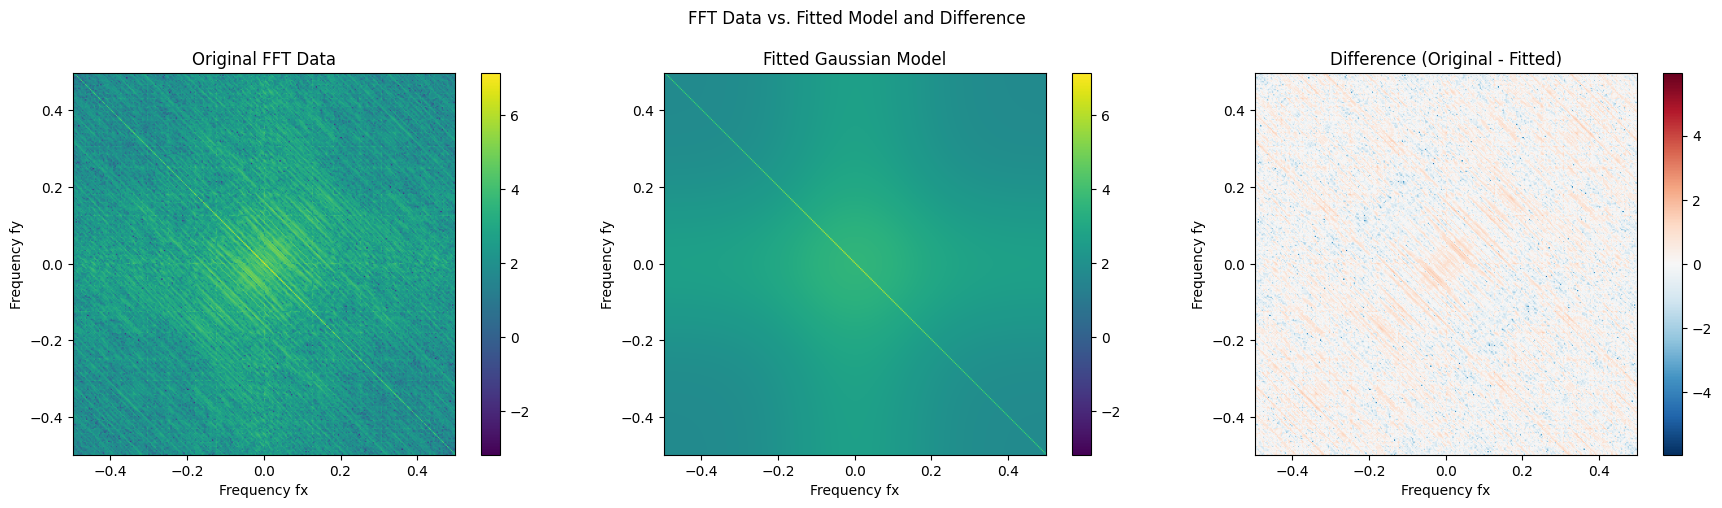

In [27]:
# Load data
prompts, activations = load_activations("pythia-14m")

# Get a sample pattern
pattern = activations[2]["blocks.4.attn.hook_pattern"][0,0]

# Plot pattern information
# plot_pattern_info(pattern)

# Fit the pattern
model, fitted_model, freqs = fit_pattern(pattern, 10000)

# Print fitted parameters
for name, param in model.named_parameters():
    print(f"{name}: {param.item()}")

# Plot comparison
plot_comparison(
    np.log(np.abs(np.fft.fftshift(np.fft.fft2(pattern @ pattern.T)))),
    fitted_model,
    freqs
)